In [1]:
library(readr)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ purrr     1.2.2
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
df <- read_delim("Курсовая1.csv", delim = ";")
print(colSums(is.na(df)))


Rows: 2111 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ";"
chr (9): Gender, family_history, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, Obesity
dbl (8): Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


        Gender            Age         Height         Weight family_history 
             0           1375              0              0              0 
          FAVC           FCVC            NCP           CAEC          SMOKE 
             0            826            640              0              0 
          CH2O            SCC            FAF            TUE           CALC 
          1290              0           1208           1153              0 
        MTRANS        Obesity 
             0              0 


In [4]:
df <- na.omit(df)
print(colSums(is.na(df)))

        Gender            Age         Height         Weight family_history 
             0              0              0              0              0 
          FAVC           FCVC            NCP           CAEC          SMOKE 
             0              0              0              0              0 
          CH2O            SCC            FAF            TUE           CALC 
             0              0              0              0              0 
        MTRANS        Obesity 
             0              0 


In [5]:
print(sum(duplicated(df)))
df <- df %>% distinct()
nrow(df)

[1] 24


[1] 491

In [6]:
nrow(df)

[1] 491

In [7]:
if (nrow(df) > 0) {
  df$BMI <- round(df$Weight / (df$Height^2), 2)
}
print(head(df, 5), width = Inf)

# A tibble: 5 × 18
  Gender   Age Height Weight family_history FAVC   FCVC   NCP CAEC      SMOKE
  <chr>  <dbl>  <dbl>  <dbl> <chr>          <chr> <dbl> <dbl> <chr>     <chr>
1 Female    21   1.62   64   yes            no        2     3 Sometimes no   
2 Female    21   1.52   56   yes            no        3     3 Sometimes yes  
3 Male      23   1.8    77   yes            no        2     3 Sometimes no   
4 Male      27   1.8    87   no             no        3     3 Sometimes no   
5 Male      22   1.78   89.8 no             no        2     1 Sometimes no   
   CH2O SCC     FAF   TUE CALC       MTRANS                Obesity            
  <dbl> <chr> <dbl> <dbl> <chr>      <chr>                 <chr>              
1     2 no        0     1 no         Public_Transportation Normal_Weight      
2     3 yes       3     0 Sometimes  Public_Transportation Normal_Weight      
3     2 no        2     1 Frequently Public_Transportation Normal_Weight      
4     2 no        2     0 Frequently Wal

In [8]:
df <- df %>% mutate(
  obese_flag = ifelse(Obesity %in% c("Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"), 1, 0)
)
print(head(df, 5), width = Inf)

# A tibble: 5 × 19
  Gender   Age Height Weight family_history FAVC   FCVC   NCP CAEC      SMOKE
  <chr>  <dbl>  <dbl>  <dbl> <chr>          <chr> <dbl> <dbl> <chr>     <chr>
1 Female    21   1.62   64   yes            no        2     3 Sometimes no   
2 Female    21   1.52   56   yes            no        3     3 Sometimes yes  
3 Male      23   1.8    77   yes            no        2     3 Sometimes no   
4 Male      27   1.8    87   no             no        3     3 Sometimes no   
5 Male      22   1.78   89.8 no             no        2     1 Sometimes no   
   CH2O SCC     FAF   TUE CALC       MTRANS                Obesity            
  <dbl> <chr> <dbl> <dbl> <chr>      <chr>                 <chr>              
1     2 no        0     1 no         Public_Transportation Normal_Weight      
2     3 yes       3     0 Sometimes  Public_Transportation Normal_Weight      
3     2 no        2     1 Frequently Public_Transportation Normal_Weight      
4     2 no        2     0 Frequently Wal

In [9]:
df <- df %>% mutate(
  Gender = as.factor(Gender),
  family_history = as.factor(family_history),
  FAVC = as.factor(FAVC),
  CAEC = as.factor(CAEC),
  SMOKE = as.factor(SMOKE),
  SCC = as.factor(SCC),
  CALC = as.factor(CALC),
  MTRANS = as.factor(MTRANS),
  Obesity = as.factor(Obesity)
)
print(head(df, 5), width = Inf)

# A tibble: 5 × 19
  Gender   Age Height Weight family_history FAVC   FCVC   NCP CAEC      SMOKE
  <fct>  <dbl>  <dbl>  <dbl> <fct>          <fct> <dbl> <dbl> <fct>     <fct>
1 Female    21   1.62   64   yes            no        2     3 Sometimes no   
2 Female    21   1.52   56   yes            no        3     3 Sometimes yes  
3 Male      23   1.8    77   yes            no        2     3 Sometimes no   
4 Male      27   1.8    87   no             no        3     3 Sometimes no   
5 Male      22   1.78   89.8 no             no        2     1 Sometimes no   
   CH2O SCC     FAF   TUE CALC       MTRANS                Obesity            
  <dbl> <fct> <dbl> <dbl> <fct>      <fct>                 <fct>              
1     2 no        0     1 no         Public_Transportation Normal_Weight      
2     3 yes       3     0 Sometimes  Public_Transportation Normal_Weight      
3     2 no        2     1 Frequently Public_Transportation Normal_Weight      
4     2 no        2     0 Frequently Wal

In [10]:
library(ggplot2)

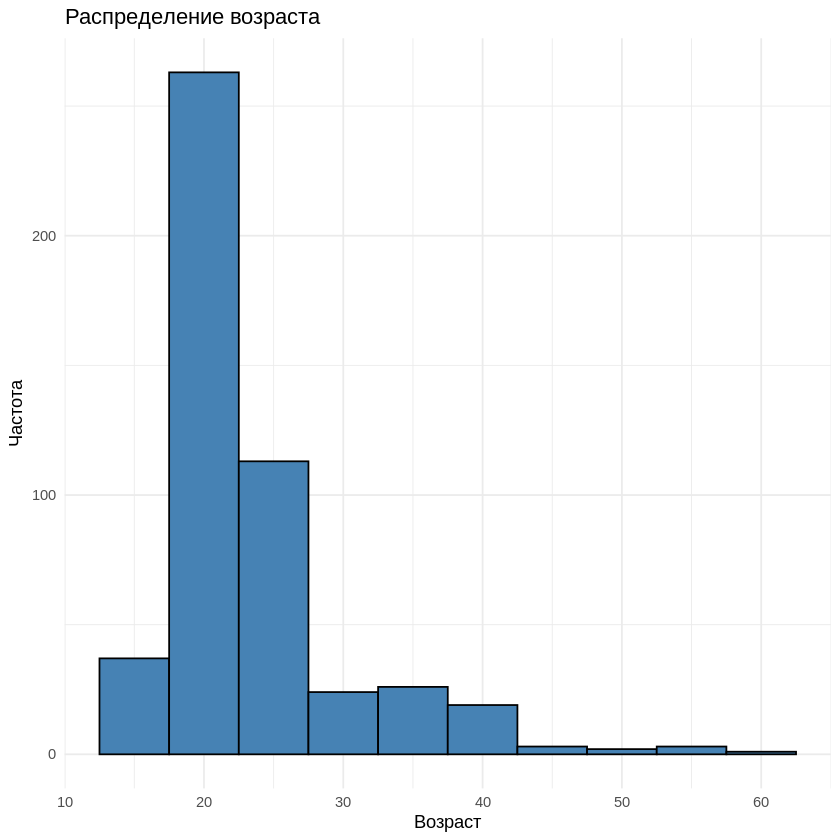

In [11]:
p1 <- ggplot(df, aes(x = Age)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "black") +
  labs(title = "Распределение возраста", x = "Возраст", y = "Частота") +
  theme_minimal()
print(p1)

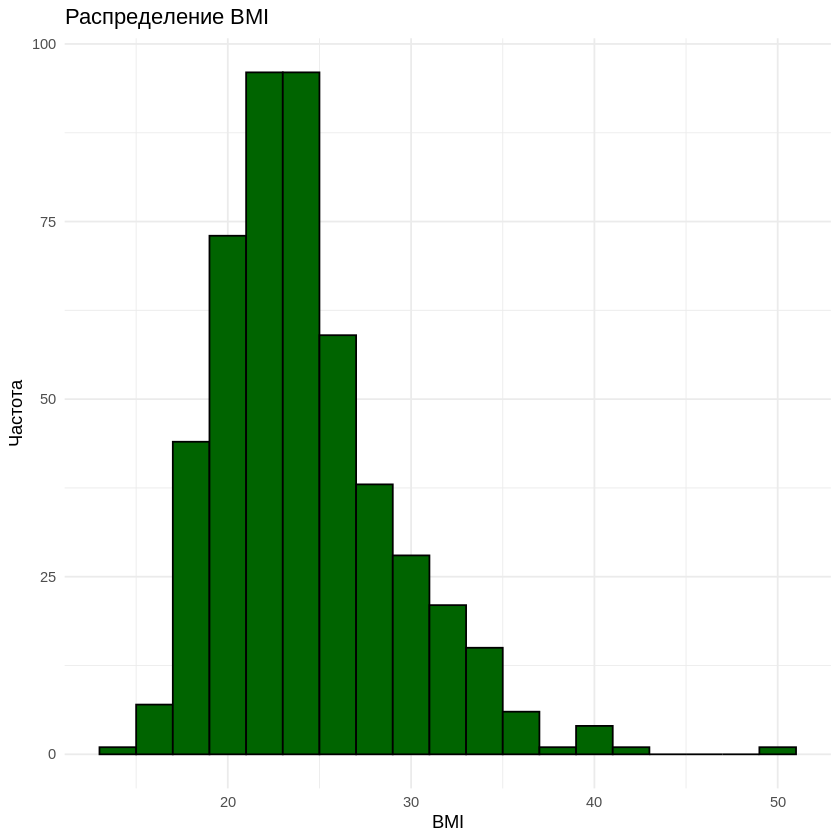

In [12]:
p2 <- ggplot(df, aes(x = BMI)) +
  geom_histogram(binwidth = 2, fill = "darkgreen", color = "black") +
  labs(title = "Распределение BMI", x = "BMI", y = "Частота") +
  theme_minimal()
print(p2)

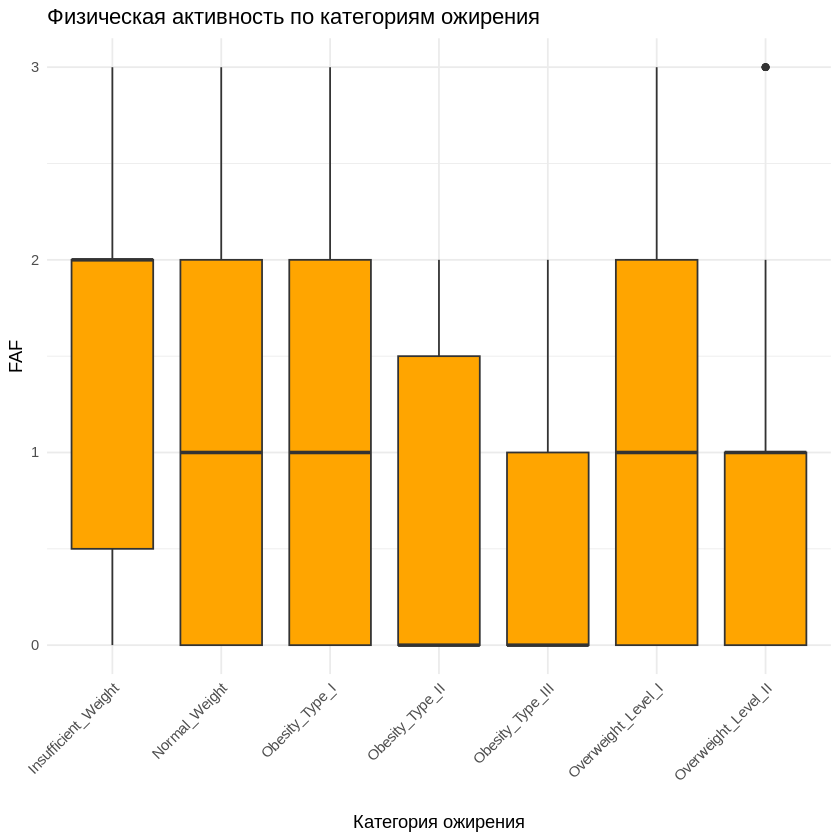

In [13]:
p3 <- ggplot(df, aes(x = Obesity, y = FAF)) +
  geom_boxplot(fill = "orange") +
  labs(title = "Физическая активность по категориям ожирения", x = "Категория ожирения", y = "FAF") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
print(p3)

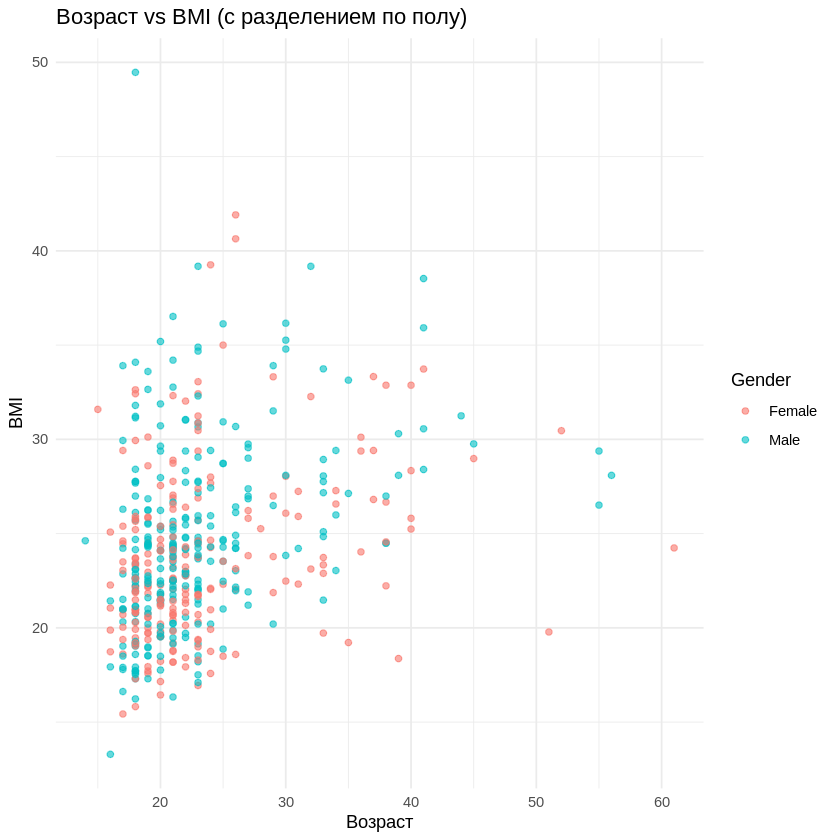

In [14]:
p4 <- ggplot(df, aes(x = Age, y = BMI, color = Gender)) +
  geom_point(alpha = 0.6) +
  labs(title = "Возраст vs BMI (с разделением по полу)", x = "Возраст", y = "BMI") +
  theme_minimal()
print(p4)

In [15]:
install.packages("corrplot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [16]:
library(corrplot)

corrplot 0.95 loaded



         Var1       Var2      Freq
29        BMI     Weight 0.8761846
83     Weight        BMI 0.8761846
90 obese_flag        BMI 0.7306324
99        BMI obese_flag 0.7306324
30 obese_flag     Weight 0.6434014
93     Weight obese_flag 0.6434014
13     Weight     Height 0.5672158
22     Height     Weight 0.5672158


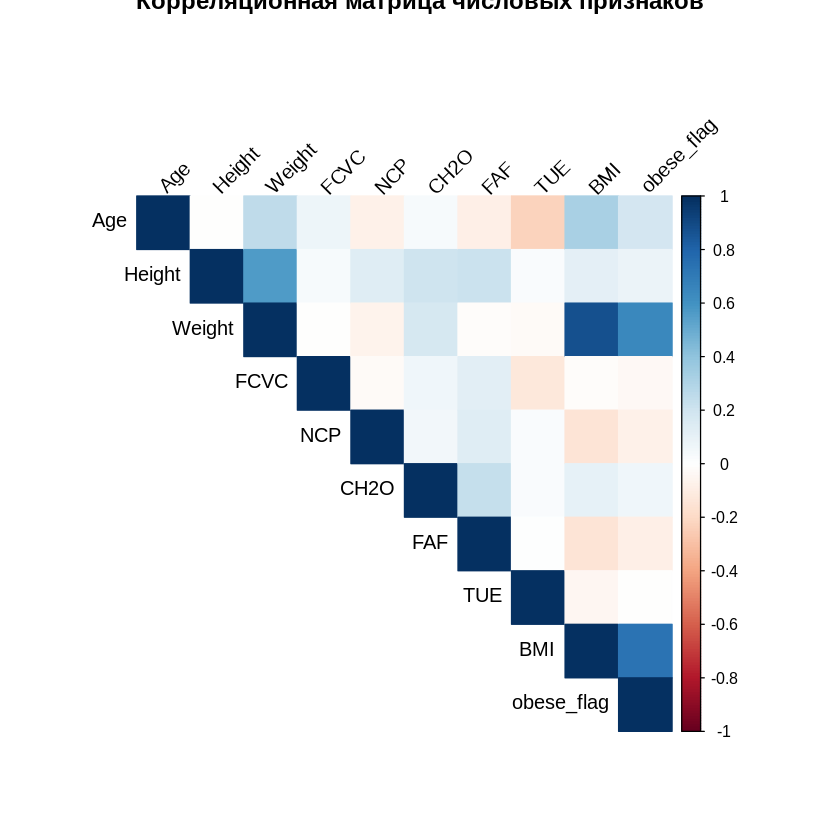

In [17]:
numeric_cols <- df %>% select(where(is.numeric))
cor_matrix <- cor(numeric_cols, use = "complete.obs")
corrplot(cor_matrix, method = "color", type = "upper",
         tl.col = "black", tl.srt = 45,
         title = "Корреляционная матрица числовых признаков")
cor_df <- as.data.frame(as.table(cor_matrix))
cor_df <- cor_df[abs(cor_df$Freq) > 0.5 & cor_df$Freq < 1, ]
cor_df <- cor_df[order(-abs(cor_df$Freq)), ]
print(cor_df)

# A tibble: 1 × 10
    Age Height Weight  FCVC   NCP  CH2O   FAF   TUE   BMI obese_flag
  <int>  <int>  <int> <int> <int> <int> <int> <int> <int>      <int>
1    57      1     10     0   151     0     0     0    11         61


Age,Gender,TUE,FAF,obese_flag
<dbl>,<fct>,<dbl>,<dbl>,<dbl>


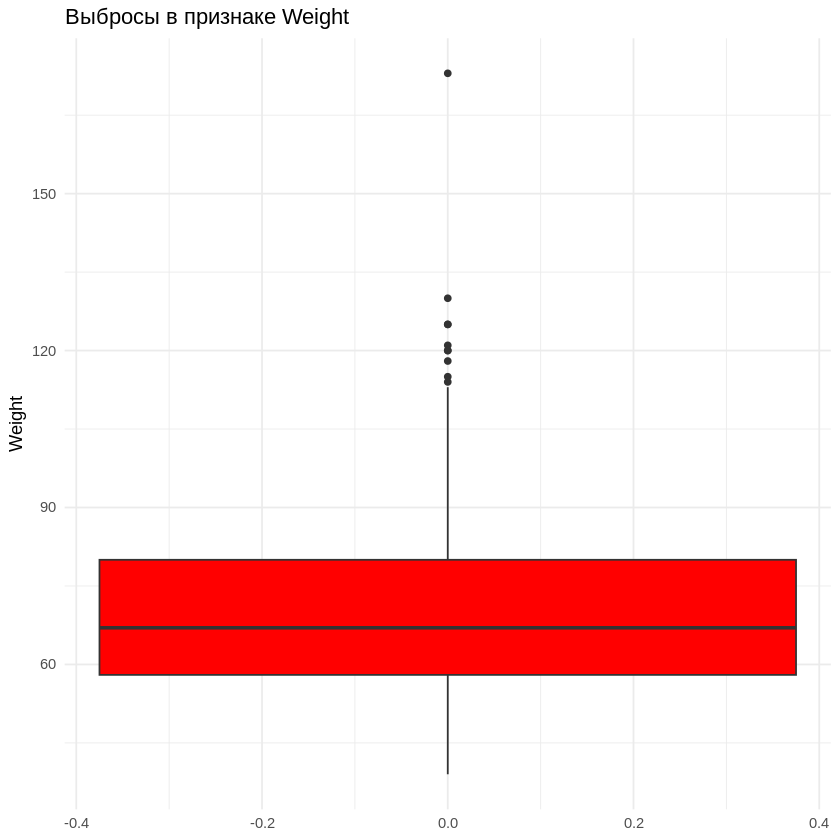

In [18]:
detect_outliers <- function(x) {
  Q1 <- quantile(x, 0.25, na.rm = TRUE)
  Q3 <- quantile(x, 0.75, na.rm = TRUE)
  IQR <- Q3 - Q1
  lower_bound <- Q1 - 1.5 * IQR
  upper_bound <- Q3 + 1.5 * IQR
  return(x < lower_bound | x > upper_bound)
}

outliers <- numeric_cols %>% summarise(across(everything(), ~ sum(detect_outliers(.))))
print(outliers)

ggplot(df, aes(y = Weight)) +
  geom_boxplot(fill = "red") +
  labs(title = "Выбросы в признаке Weight", y = "Weight") +
  theme_minimal()

df %>% filter(TUE > 15) %>% select(Age, Gender, TUE, FAF, obese_flag)

In [19]:
install.packages("skimr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [20]:
library(skimr)

In [21]:
df %>%
  summarise(
    mean_BMI = mean(BMI, na.rm = TRUE),
    median_BMI = median(BMI, na.rm = TRUE),
    sd_BMI = sd(BMI, na.rm = TRUE),
    min_BMI = min(BMI, na.rm = TRUE),
    max_BMI = max(BMI, na.rm = TRUE),
    Q1_BMI = quantile(BMI, 0.25, na.rm = TRUE),
    Q3_BMI = quantile(BMI, 0.75, na.rm = TRUE)
  )

df %>% count(Gender)
df %>% count(family_history)
df %>% count(obese_flag)

mean_BMI,median_BMI,sd_BMI,min_BMI,max_BMI,Q1_BMI,Q3_BMI
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
24.30477,23.67,4.806258,13.29,49.47,20.975,26.83


Gender,n
<fct>,<int>
Female,223
Male,268


family_history,n
<fct>,<int>
no,193
yes,298


obese_flag,n
<dbl>,<int>
0,430
1,61


In [22]:
t_test_result <- t.test(BMI ~ Gender, data = df)
print(t_test_result)

anova_result <- aov(FAF ~ MTRANS, data = df)
summary(anova_result)

chisq_test_result <- chisq.test(table(df$family_history, df$obese_flag))
print(chisq_test_result)


	Welch Two Sample t-test

data:  BMI by Gender
t = -2.5376, df = 485.9, p-value = 0.01147
alternative hypothesis: true difference in means between group Female and group Male is not equal to 0
95 percent confidence interval:
 -1.9323616 -0.2458166
sample estimates:
mean in group Female   mean in group Male 
            23.71031             24.79940 



             Df Sum Sq Mean Sq F value  Pr(>F)   
MTRANS        4   18.2   4.556   4.416 0.00163 **
Residuals   486  501.4   1.032                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


	Pearson's Chi-squared test with Yates' continuity correction

data:  table(df$family_history, df$obese_flag)
X-squared = 18.797, df = 1, p-value = 1.454e-05



In [23]:
df_reg <- df %>% select(
  obese_flag, Age, Gender, FCVC, NCP, CH2O, FAF, TUE,
  FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, family_history
)
set.seed(42)
train_indices <- sample(1:nrow(df_reg), size = 0.7 * nrow(df_reg))
train_data <- df_reg[train_indices, ]
test_data <- df_reg[-train_indices, ]
model <- glm(obese_flag ~ . - obese_flag,
             data = train_data,
             family = binomial(link = "logit"))
summary(model)
predictions_prob <- predict(model, newdata = test_data, type = "response")
predictions_class <- ifelse(predictions_prob > 0.5, 1, 0)
conf_table <- table(Predicted = predictions_class, Actual = test_data$obese_flag)
print(conf_table)
accuracy <- sum(diag(conf_table)) / sum(conf_table)
TP <- conf_table[2,2]; FP <- conf_table[2,1]
TN <- conf_table[1,1]; FN <- conf_table[1,2]
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
f1 <- 2 * precision * recall / (precision + recall)
cat("Accuracy:", round(accuracy, 4), "\n")
cat("Precision:", round(precision, 4), "\n")
cat("Recall:", round(recall, 4), "\n")
cat("F1-score:", round(f1, 4), "\n")



Call:
glm(formula = obese_flag ~ . - obese_flag, family = binomial(link = "logit"), 
    data = train_data)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)   
(Intercept)                  -18.61463 3956.18076  -0.005  0.99625   
Age                            0.05533    0.02985   1.854  0.06375 . 
GenderMale                     0.55931    0.40809   1.371  0.17052   
FCVC                          -0.03008    0.34232  -0.088  0.92997   
NCP                           -0.21287    0.20052  -1.062  0.28841   
CH2O                          -0.04218    0.28684  -0.147  0.88308   
FAF                           -0.10065    0.19585  -0.514  0.60730   
TUE                            0.57967    0.26225   2.210  0.02708 * 
FAVCyes                       -0.12365    0.40984  -0.302  0.76288   
CAECFrequently                -1.83107    0.79357  -2.307  0.02103 * 
CAECno                       -15.11890 1195.69111  -0.013  0.98991   
CAECSometimes                 -0.081

         Actual
Predicted   0   1
        0 126  18
        1   3   1
Accuracy: 0.8581 
Precision: 0.25 
Recall: 0.0526 
F1-score: 0.087 


In [24]:
library(class)

In [25]:
normalize <- function(x) {
  return((x - min(x)) / (max(x) - min(x)))
}

knn_features <- train_data %>% select(Age, FCVC, NCP, CH2O, FAF, TUE)
knn_features <- as.data.frame(lapply(knn_features, normalize))

knn_test_features <- test_data %>% select(Age, FCVC, NCP, CH2O, FAF, TUE)
knn_test_features <- as.data.frame(lapply(knn_test_features, normalize))

set.seed(42)
accuracy_k <- c()
for (k in 1:20) {
  pred <- knn(train = knn_features,
              test = knn_test_features,
              cl = train_data$obese_flag,
              k = k)
  accuracy_k[k] <- mean(pred == test_data$obese_flag)
}

best_k <- which.max(accuracy_k)
print(paste("Оптимальное k:", best_k))

knn_pred <- knn(train = knn_features,
                test = knn_test_features,
                cl = train_data$obese_flag,
                k = best_k)

conf_table <- table(Predicted = knn_pred, Actual = test_data$obese_flag)
print(conf_table)

accuracy <- sum(diag(conf_table)) / sum(conf_table)
TP <- conf_table[2,2]
FP <- conf_table[2,1]
FN <- conf_table[1,2]

precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
f1 <- 2 * precision * recall / (precision + recall)

cat("Accuracy:", round(accuracy, 4), "\n")
cat("Precision:", round(precision, 4), "\n")
cat("Recall:", round(recall, 4), "\n")
cat("F1-score:", round(f1, 4), "\n")

[1] "Оптимальное k: 6"
         Actual
Predicted   0   1
        0 128  19
        1   1   0
Accuracy: 0.8649 
Precision: 0 
Recall: 0 
F1-score: NaN 


         Age        BMI       FCVC        NCP        CH2O        FAF
1  1.5066218  1.0562703  0.2562890 -0.3159739 -0.01010439 -0.2683484
2 -0.3647063 -0.2804095  0.3402632  0.4640722  0.53576848  0.8545982
3 -0.3588216 -0.2317892 -0.3828808 -0.2348145 -0.42425153 -0.5678008
          TUE
1 -0.47585952
2  0.07748889
3  0.14349368



  1   2   3 
 95 176 220 

   
      0   1
  1  59  36
  2 164  12
  3 207  13

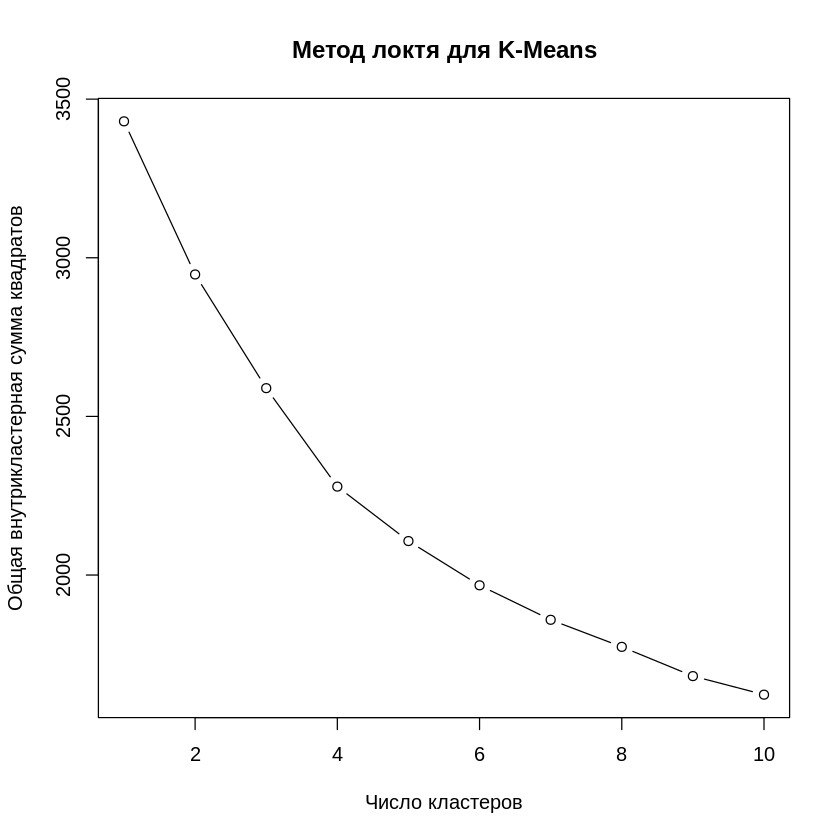

   
      1   2   3
  1   5  61  29
  2  60 107   9
  3 120  37  63

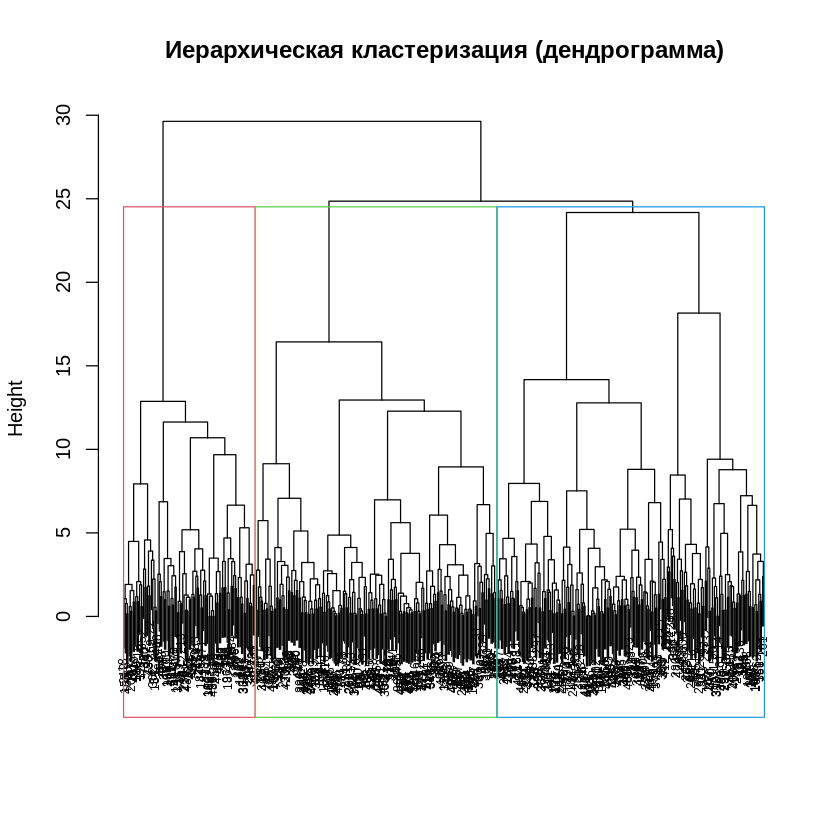

In [26]:
cluster_data <- df %>% select(Age, BMI, FCVC, NCP, CH2O, FAF, TUE)
cluster_scaled <- scale(cluster_data)
wss <- sapply(1:10, function(k) {
  kmeans(cluster_scaled, centers = k, nstart = 25)$tot.withinss
})

plot(1:10, wss, type = "b",
     xlab = "Число кластеров",
     ylab = "Общая внутрикластерная сумма квадратов",
     main = "Метод локтя для K-Means")

set.seed(42)
kmeans_result <- kmeans(cluster_scaled, centers = 3, nstart = 25)
df$kmeans_cluster <- kmeans_result$cluster

print(kmeans_result$centers)
table(kmeans_result$cluster)
table(df$kmeans_cluster, df$obese_flag)

dist_matrix <- dist(cluster_scaled, method = "euclidean")

hc <- hclust(dist_matrix, method = "ward.D2")
plot(hc, main = "Иерархическая кластеризация (дендрограмма)",
     xlab = "", sub = "", cex = 0.6)

rect.hclust(hc, k = 3, border = 2:4)
df$hclust_cluster <- cutree(hc, k = 3)
table(df$kmeans_cluster, df$hclust_cluster)

In [27]:
install.packages("plotly")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’




In [28]:
library(ggplot2)
library(plotly)


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.015”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 2.015”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  3.3199e-17”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.015”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 2.015”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  7.7973e-17”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = para

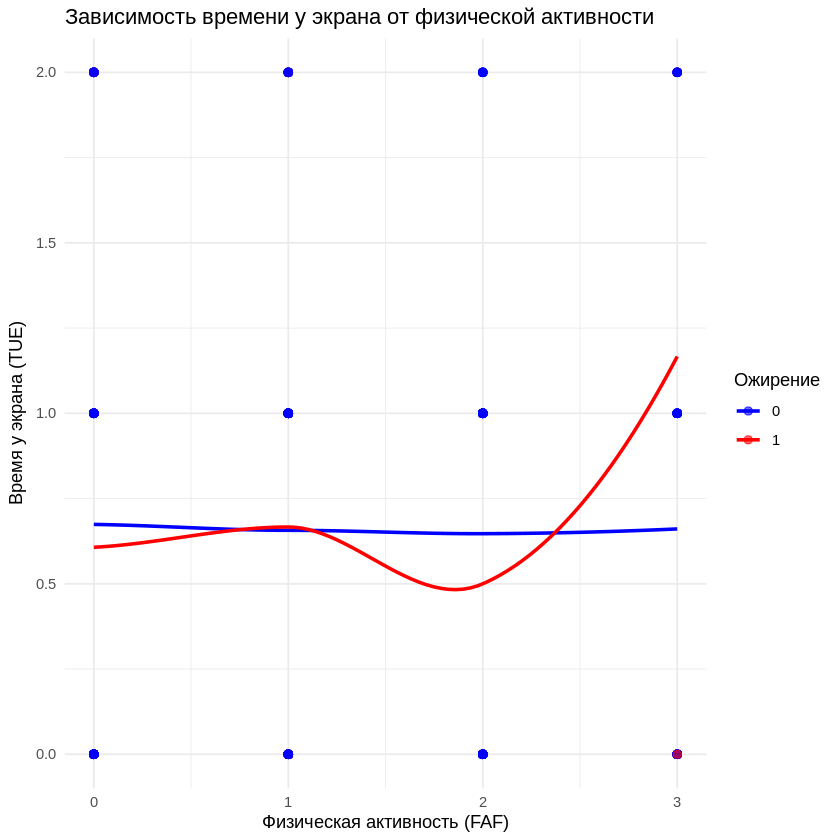

In [29]:
ggplot(df, aes(x = FAF, y = TUE, color = factor(obese_flag))) +
  geom_point(alpha = 0.6, size = 2) +
  geom_smooth(method = "loess", se = FALSE) +
  labs(title = "Зависимость времени у экрана от физической активности",
       x = "Физическая активность (FAF)", y = "Время у экрана (TUE)") +
  scale_color_manual(values = c("blue", "red"), name = "Ожирение") +
  theme_minimal()